# Part 5 Task   

**RQ: Are there distinct patterns in interest about kdramas?** 

Plan:   
1. Get a **list** of title names of each kdrama
2. Access daily pageviews for each kdrama and store into csv for each 
3. Graph 1: calculate total pageviews (sum across "count" column)
4. Graph 2: identify the maximum in "count" and in an additional column of "centered-date", label it as 0 and negative integers before/positive integers after. 

**Table of Contents**  
1. [Exploring the kdramas_2023.csv](#sec1)
2. [Getting data from Wiki](#sec2)
3. [Recreating Graph 1](#sec3)
4. [Recreating Graph 2](#sec4)

<a id="sec1"></a>
## 1. Exploring the kdramas_2023.csv

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv('kdramas_2023.csv')
df.shape

(213, 18)

In [4]:
df.columns

Index(['Unnamed: 0', 'Year', 'Title_English', 'Episodes', 'Popularity',
       'Aired', 'Aired On', 'Duration', 'Genres', 'Tags', 'Summary',
       'Title_Korean', 'Also Known As', 'Content Rating', 'Score_Votes',
       'Score', 'Ranked', 'Watchers'],
      dtype='object')

In [5]:
df.head()

,Unnamed: 0,Year,Title_English,Episodes,Popularity,Aired,Aired On,Duration,Genres,Tags,Summary,Title_Korean,Also Known As,Content Rating,Score_Votes,Score,Ranked,Watchers
0,0,2023,High Cookie (2023),20,1638,"Oct 23, 2023 - Nov 23, 2023",NaN,34 min.,"['Thriller', 'Mystery', 'Youth', 'Fantasy']","['Bully Supporting Character', 'Student Suppor...",A teen fantasy thriller drama that tells the s...,하이쿠키,"Hai Kuki , Haikuki , Hi Cookie , Привет, печен...",18+ Restricted (violence & profanity),2440,7.3,8082,15709
1,1,2023,Strangers Again (2023),12,1515,"Jan 18, 2023 - Feb 23, 2023","Wednesday, Thursday",1 hr. 10 min.,"['Law', 'Romance', 'Drama']","[""Bickering Mains' Relationship"", 'Ex-spouse R...","Divorce lawyer Oh Ha Ra, known as the “goddess...",남이 될 수 있을까?,"Can I Be Someone Else , Can I Be Someone Else?...",15+ - Teens 15 or older,5187,7.2,9766,17025
2,2,2023,Hello! This Is Starbucks (2023),19,99999,"Jun 20, 2023 - Jul 27, 2023","Tuesday, Wednesday, Thursday",1 min.,['Life'],"['Café Setting', 'Short Length Series', 'Web S...",This web drama deals with a theme based on the...,안녕하세요! 스타벅스입니다,Annyeonghaseyo! Seutabeokseuibnida,Not Yet Rated,5,5.9,99999,105
3,3,2023,Adult Kids (2023),8,9473,"Jun 19, 2023 - Aug 7, 2023",Monday,10 min.,"['Life', 'Drama']","['Female Centered Plot', 'Short Length Series'...",A hyper-realistic drama depicting the daily li...,어른애들,"Crianças Adultas , Eoreunaedeul , The Adult Li...",Not Yet Rated,181,7.1,10086,1250
4,4,2023,My Demon (2023),16,40,"Nov 24, 2023 - Jan 20, 2024","Friday, Saturday",1 hr. 6 min.,"['Action', 'Comedy', 'Romance', 'Fantasy']","['Demon Male Lead', 'Supernatural', 'Heiress F...",Do Do Hee is the successor of the Future Group...,마이데몬,"Demonul Șarmant , Maidemon , Meu Demônio Favor...",15+ - Teens 15 or older,97628,8.3,1177,165957


In [9]:
df[df['Title_English']=='My Demon (2023)']

,Unnamed: 0,Year,Title_English,Episodes,Popularity,Aired,Aired On,Duration,Genres,Tags,Summary,Title_Korean,Also Known As,Content Rating,Score_Votes,Score,Ranked,Watchers
4,4,2023,My Demon (2023),16,40,"Nov 24, 2023 - Jan 20, 2024","Friday, Saturday",1 hr. 6 min.,"['Action', 'Comedy', 'Romance', 'Fantasy']","['Demon Male Lead', 'Supernatural', 'Heiress F...",Do Do Hee is the successor of the Future Group...,마이데몬,"Demonul Șarmant , Maidemon , Meu Demônio Favor...",15+ - Teens 15 or older,97628,8.3,1177,165957


Let's make a list of kdramas titles without the year.

In [5]:
kdramas_split = df['Title_English'].apply(lambda x: x.split(' ('))
kdramas_series = kdramas_split.apply(lambda x: x[0])
kdramas_list = kdramas_series.tolist()
kdramas_list[:5]


['High Cookie',
 'Strangers Again',
 'Hello! This Is Starbucks',
 'Adult Kids',
 'My Demon']

In [6]:
len(kdramas_list)

213

<a id="sec2"></a>
## 2. Getting Data from Wiki

Let's first try to play around with one page of a kdrama.

In [8]:
from mwclient import Site
site = Site('en.wikipedia.org')
page = site.pages[kdramas_list[0]]
page

<Page object 'High Cookie' for <Site object 'en.wikipedia.org/w/'>>

In [10]:
from mwviews.api import PageviewsClient

p = PageviewsClient(user_agent="Kdrama Lover (wendy_wellesley@gmail.com)")

data = p.article_views('en.wikipedia', 'High Cookie',  start='20260601', end='20260608') 
type(data)

collections.defaultdict

Let's make it into a dictionary so it's easier to parse.

In [11]:
data = dict(data)

THe keys are all of the dates, which we want as the indices for corresponding pageviews.

In [12]:
data.keys()

dict_keys([datetime.datetime(2026, 6, 1, 0, 0), datetime.datetime(2026, 6, 2, 0, 0), datetime.datetime(2026, 6, 3, 0, 0), datetime.datetime(2026, 6, 4, 0, 0), datetime.datetime(2026, 6, 5, 0, 0), datetime.datetime(2026, 6, 6, 0, 0), datetime.datetime(2026, 6, 7, 0, 0), datetime.datetime(2026, 6, 8, 0, 0)])

Now we want to try to only extract the values of values ("None" or a number), which will be our pageviews data.

In [13]:
for v in data.values():
    print(v.values())

dict_values([101])
dict_values([146])
dict_values([126])
dict_values([112])
dict_values([241])
dict_values([552])
dict_values([586])
dict_values([571])


Let's try to write a loop so that we extract what we need:

In [14]:
new_dict = {}
for date, inner_dict in data.items(): # we are constructing a dictionary so that the date corresponds to the views directly
    for key, value in inner_dict.items():
        if key not in new_dict:
            new_dict[key] = {}
        new_dict[key][date] = value

In [15]:
new_dict

{'High_Cookie': {datetime.datetime(2026, 6, 1, 0, 0): 101,
  datetime.datetime(2026, 6, 2, 0, 0): 146,
  datetime.datetime(2026, 6, 3, 0, 0): 126,
  datetime.datetime(2026, 6, 4, 0, 0): 112,
  datetime.datetime(2026, 6, 5, 0, 0): 241,
  datetime.datetime(2026, 6, 6, 0, 0): 552,
  datetime.datetime(2026, 6, 7, 0, 0): 586,
  datetime.datetime(2026, 6, 8, 0, 0): 571}}

PUTTING IT ALL TOGEHTER for ALL kdramas:

In [21]:
from mwviews.api import PageviewsClient
from requests import HTTPError
import time

p = PageviewsClient(user_agent="Student researcher interested in kdramas (wellesley_wendy@gmail.com)")

total = {}
exception_list = []

for k in kdramas_list:
    page = site.pages[k]
    # revisions = [rev for rev in page.revisions()]
    # if len(revisions) > 0: # this is to make sure that the page actually has a history    

    # the following if blcok is to check if the wikipedia page for the kdrama exists or not
    if not page.exists:
        print(f"Skipping '{k}': Page does not exist.")
        continue

    try:
        data = p.article_views('en.wikipedia', k, start='20220601', end='20240601')
            
        new_dict = {}
        for date, inner_dict in data.items(): # we are constructing a dictionary so that the date corresponds to the views directly
            for key, value in inner_dict.items():
                if key not in new_dict:
                    new_dict[key] = {}
                new_dict[key][date] = value
            # kdrama_views = dict(data.items()) # so the key of date can correspond to value of views directly
        total.update(new_dict)
    except Exception:
        print(f"ERROR while fetching and parsing {k}")
        exception_list.append(k)
    except HTTPError:
        print("Too many requests")
        exception_list.append(k)
        time.sleep(5)  # Back off if throttled
    else:
        pass
    time.sleep(0.5)

Skipping 'Hello! This Is Starbucks': Page does not exist.
Skipping 'Adult Kids': Page does not exist.
Skipping 'The Matchmakers': Page does not exist.
Skipping 'D.P. Season 2': Page does not exist.
Skipping 'Couple Scandal Season 2': Page does not exist.
Skipping 'Those Who Pass Through Gimpo City': Page does not exist.
Skipping 'Youth on the Road': Page does not exist.
Skipping 'We Only See Each Other at Night': Page does not exist.
Skipping 'Last Taxi': Page does not exist.
Skipping 'That Is How We Are': Page does not exist.
Skipping 'KBS Drama Special 2023': Page does not exist.
Skipping 'Campus Freshman': Page does not exist.
Skipping 'Super Junior: The Last Man Standing': Page does not exist.
ERROR while fetching and parsing ['https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/Soundtrack_%232/daily/2022060100/2024060100']
ERROR while fetching and parsing Soundtrack #2


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/mwviews/api/pageviews.py", line 146, in article_views
    raise Exception(
        'The pageview API returned nothing useful at: {}'.format(urls)
    )
Exception: The pageview API returned nothing useful at: ['https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/Soundtrack_%232/daily/2022060100/2024060100']


Skipping 'Snow White and the Water Travel Agency': Page does not exist.
Skipping 'Bump Up Business': Page does not exist.
Skipping 'Joseon Attorney: A Morality': Page does not exist.
Skipping 'Taxi Driver Season 2': Page does not exist.
Skipping 'tvN O'PENing: Shoot Me': Page does not exist.
Skipping 'Because We Are Different': Page does not exist.
Skipping 'Strong Girl Nam Soon': Page does not exist.
Skipping 'Welcome to the Lesbian Bar': Page does not exist.
Skipping 'Unrealistic Youtuber': Page does not exist.
Skipping 'Jun & Jun': Page does not exist.
Skipping 'Why Opposites Attract Season 2': Page does not exist.
Skipping 'The Glory Part 2': Page does not exist.
Skipping 'The Villain of Romance': Page does not exist.
Skipping 'Shadow Detective Season 2': Page does not exist.
Skipping 'The Emotion': Page does not exist.
Skipping 'It Was Spring': Page does not exist.
Skipping 'Blue Temperature': Page does not exist.
Skipping 'My Sister Season 2': Page does not exist.
Skipping 'Our D

Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/mwviews/api/pageviews.py", line 146, in article_views
    raise Exception(
        'The pageview API returned nothing useful at: {}'.format(urls)
    )
Exception: The pageview API returned nothing useful at: ['https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/Between_Him_and_Her/daily/2022060100/2024060100']


Skipping 'Bronze? Gold!': Page does not exist.
Skipping 'Something Unique': Page does not exist.
Skipping 'Love Class Season 2': Page does not exist.
Skipping 'Straight Sassy Season 2': Page does not exist.
ERROR while fetching and parsing ['https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/Payback%3A_Money_and_Power/daily/2022060100/2024060100']
ERROR while fetching and parsing Payback: Money and Power


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/mwviews/api/pageviews.py", line 146, in article_views
    raise Exception(
        'The pageview API returned nothing useful at: {}'.format(urls)
    )
Exception: The pageview API returned nothing useful at: ['https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/Payback%3A_Money_and_Power/daily/2022060100/2024060100']


Skipping 'Reincarnated Partners': Page does not exist.
Skipping 'Couple Scandal': Page does not exist.
ERROR while fetching and parsing ['https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/Unintentional_Love_Story/daily/2022060100/2024060100']
ERROR while fetching and parsing Unintentional Love Story


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/mwviews/api/pageviews.py", line 146, in article_views
    raise Exception(
        'The pageview API returned nothing useful at: {}'.format(urls)
    )
Exception: The pageview API returned nothing useful at: ['https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/Unintentional_Love_Story/daily/2022060100/2024060100']


Skipping 'Usual Yet Unusual Season 2': Page does not exist.
Skipping 'Golf's True Colors': Page does not exist.
Skipping 'Love Mate': Page does not exist.
Skipping 'Secret Playlist': Page does not exist.
Skipping 'Ridiculous, but the Law of Maintenance': Page does not exist.
Skipping 'Duty after School: Part 2': Page does not exist.
Skipping 'Bully and Nerd': Page does not exist.
Skipping 'Sound Candy': Page does not exist.
Skipping 'Only You, My First Love': Page does not exist.
Skipping 'My Dearest Part 2': Page does not exist.
Skipping 'My 20th Twenty': Page does not exist.
Skipping 'Because I Live in America': Page does not exist.
Skipping 'The Eighth Sense': Page does not exist.
Skipping 'Convenience Store Bejjangi': Page does not exist.
Skipping 'The First Responders Season 2': Page does not exist.
Skipping 'Between Friendship and Love Season 4': Page does not exist.
Skipping 'Journey to Mirae': Page does not exist.
Skipping 'Dreaming Island': Page does not exist.
Skipping 'Ririk

HTTPError: 429 Client Error: Too Many Requests for url: https://en.wikipedia.org/w/api.php?prop=info&titles=Night+Has+Come&inprop=protection&continue=&meta=userinfo&uiprop=blockinfo%7Chasmsg&action=query&format=json

In [25]:
len(total)

85

We only got 85 kdramas, but we will continue with this for now.

In [26]:
len(total['High_Cookie'])

732

732 is the number of days between the start and end date!

In [27]:
total['Strangers_Again']

{datetime.datetime(2022, 6, 1, 0, 0): 4,
 datetime.datetime(2022, 6, 2, 0, 0): 1,
 datetime.datetime(2022, 6, 3, 0, 0): 7,
 datetime.datetime(2022, 6, 4, 0, 0): 3,
 datetime.datetime(2022, 6, 5, 0, 0): 2,
 datetime.datetime(2022, 6, 6, 0, 0): 3,
 datetime.datetime(2022, 6, 7, 0, 0): 4,
 datetime.datetime(2022, 6, 8, 0, 0): 4,
 datetime.datetime(2022, 6, 9, 0, 0): 2,
 datetime.datetime(2022, 6, 10, 0, 0): 8,
 datetime.datetime(2022, 6, 11, 0, 0): 8,
 datetime.datetime(2022, 6, 12, 0, 0): 6,
 datetime.datetime(2022, 6, 13, 0, 0): 1,
 datetime.datetime(2022, 6, 14, 0, 0): 8,
 datetime.datetime(2022, 6, 15, 0, 0): 5,
 datetime.datetime(2022, 6, 16, 0, 0): 6,
 datetime.datetime(2022, 6, 17, 0, 0): 4,
 datetime.datetime(2022, 6, 18, 0, 0): 6,
 datetime.datetime(2022, 6, 19, 0, 0): None,
 datetime.datetime(2022, 6, 20, 0, 0): 6,
 datetime.datetime(2022, 6, 21, 0, 0): 3,
 datetime.datetime(2022, 6, 22, 0, 0): 8,
 datetime.datetime(2022, 6, 23, 0, 0): 4,
 datetime.datetime(2022, 6, 24, 0, 0): 5

However, we can see that there were NO views around this arbitrary start date that we set, because the page likely has not been created yet. Therefore, all None values must be set to 0 later. We can further investigate this:

In [28]:
revisions = [rev for rev in page.revisions()]
len(revisions)

78

The last entry of revisions would be the creation date of the page!

In [29]:
revisions[-1]

OrderedDict([('revid', 1153832542),
             ('parentid', 0),
             ('user', 'D.18th'),
             ('timestamp',
              time.struct_time(tm_year=2023, tm_mon=5, tm_mday=8, tm_hour=16, tm_min=3, tm_sec=55, tm_wday=0, tm_yday=128, tm_isdst=-1)),
             ('comment',
              "[[WP:AES|←]]Created page with '{{Short description|2023 South Korean web series}} {{Use mdy dates|date=May 2023}} {{Infobox television | image                =  | image_upright        =  | image_size           =  | image_alt            =  | caption              =  | alt_name             =  | native_name          = {{Infobox Korean television name|hangul=우리가 사랑했던 모든 것|hanja=우리가 思郞했던 모든 것|rr=Uriga saranghaettdeon modeun geot|mr=Uriga saranghaettŏn m...'")])

Now, let's turn the timestamp in the time.struct_time form into a datetime object so we can parse it easily!

In [30]:
from time import mktime
from datetime import datetime

In [31]:
creation_date = datetime.fromtimestamp(mktime(revisions[-1]['timestamp']))
creation_date

datetime.datetime(2023, 5, 8, 16, 3, 55)

<a id="sec3"></a>
## 3. Recreating Graph 1

In [34]:
df = pd.DataFrame(total)
df.head()

,High_Cookie,Strangers_Again,My_Demon,Longing_for_You,Intern,Why_R_U?,Doona!,Love_to_Hate_You,Race,Boyhood,...,The_Kidnapping_Day,Better_Things,The_Good_Bad_Mother,Vigilante,Gyeongseong_Creature,A_Shoulder_to_Cry_On,A_Good_Day_to_Be_a_Dog,Perfect_Marriage_Revenge,Three_of_Us,All_That_We_Loved
2022-06-01,NaN,4.0,NaN,2.0,58,115,NaN,40,150,28,...,NaN,11.0,NaN,280,NaN,7.0,NaN,NaN,1.0,NaN
2022-06-02,NaN,1.0,NaN,2.0,47,100,NaN,60,197,15,...,NaN,12.0,NaN,254,NaN,2.0,NaN,NaN,NaN,NaN
2022-06-03,NaN,7.0,NaN,2.0,52,79,NaN,32,153,28,...,NaN,18.0,NaN,248,NaN,6.0,NaN,NaN,NaN,NaN
2022-06-04,NaN,3.0,NaN,4.0,41,86,NaN,27,156,18,...,NaN,21.0,NaN,383,NaN,3.0,NaN,NaN,1.0,NaN
2022-06-05,NaN,2.0,NaN,3.0,40,75,NaN,39,159,23,...,NaN,10.0,NaN,548,NaN,21.0,NaN,NaN,NaN,NaN


Making several logistical adjustments:

In [35]:
df = df.fillna(0)
df = df.convert_dtypes()

Calculating the aggregate of a column:

In [36]:
df.High_Cookie.sum()

np.int64(104622)

In [37]:
pageviews_sums = df.sum().sort_values(ascending=True)
pageviews_sums

A_Breeze_of_Love            102
Star_Struck                 235
Cold_Blooded_Intern         288
To_Be_Honest                320
Tree_Man                    377
                         ...   
Death's_Game            1963050
Twinkling_Watermelon    2061432
Gyeongseong_Creature    2081110
King_the_Land           2697595
My_Demon                2822146
Length: 85, dtype: Int64

In [43]:
top_20_views = pageviews_sums[-20:]

In [38]:
import matplotlib.pyplot as plt

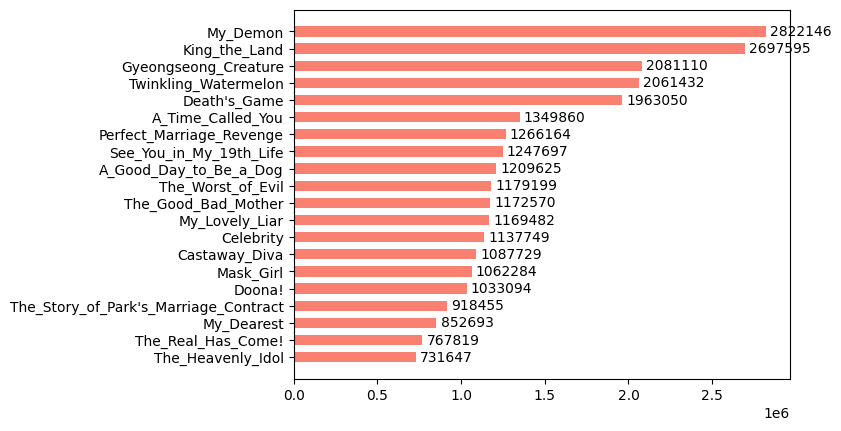

In [44]:
fig, ax = plt.subplots()
chart = ax.barh(top_20_views.index, top_20_views.values, color='salmon', height=0.6)

ax.bar_label(chart, fmt='%.0f', padding=3)
plt.show()

<a id="sec4"></a>
## 4. Recreating Graph 2

The idea is to find the row with the maximum number of views and the corresponding date, then creating a new column with a centered date.

In [45]:
df[df.High_Cookie==df.High_Cookie.max()]

,High_Cookie,Strangers_Again,My_Demon,Longing_for_You,Intern,Why_R_U?,Doona!,Love_to_Hate_You,Race,Boyhood,...,The_Kidnapping_Day,Better_Things,The_Good_Bad_Mother,Vigilante,Gyeongseong_Creature,A_Shoulder_to_Cry_On,A_Good_Day_to_Be_a_Dog,Perfect_Marriage_Revenge,Three_of_Us,All_That_We_Loved
2023-11-24,2277,6,24202,1,29,37,4216,68,254,11,...,461,8,877,227,4403,2,6068,24263,1,110


This is not really going to work because we only want one of the dramas if it's based on the maximum value for ONE drama. So we will revert back to series.

In [46]:
series_dict = {key: pd.Series(val) for key, val in total.items()}
len(series_dict)

85

In [47]:
series_dict['High_Cookie'].max()

np.float64(2277.0)

In [48]:
temp_df = pd.DataFrame(series_dict['High_Cookie'], columns =['views']).fillna(0)
temp_df

,views
2022-06-01,0.0
2022-06-02,0.0
2022-06-03,0.0
2022-06-04,0.0
2022-06-05,0.0
...,...
2024-05-28,123.0
2024-05-29,110.0
2024-05-30,117.0
2024-05-31,129.0


In [49]:
temp_df[temp_df['views'] == temp_df['views'].max()]

,views
2023-11-24,2277.0


In [50]:
maximum_date = temp_df[temp_df['views'] == temp_df['views'].max()].index
temp_df['date'] = temp_df.index

Now we will make a new column!

In [51]:
temp_df['centered_date'] = temp_df.date.apply(lambda x: (x-maximum_date).days.item())

In [52]:
temp_df

,views,date,centered_date
2022-06-01,0.0,2022-06-01,-541
2022-06-02,0.0,2022-06-02,-540
2022-06-03,0.0,2022-06-03,-539
2022-06-04,0.0,2022-06-04,-538
2022-06-05,0.0,2022-06-05,-537
...,...,...,...
2024-05-28,123.0,2024-05-28,186
2024-05-29,110.0,2024-05-29,187
2024-05-30,117.0,2024-05-30,188
2024-05-31,129.0,2024-05-31,189


Let's try to generate an example of the graph:

(-200.0, 200.0)

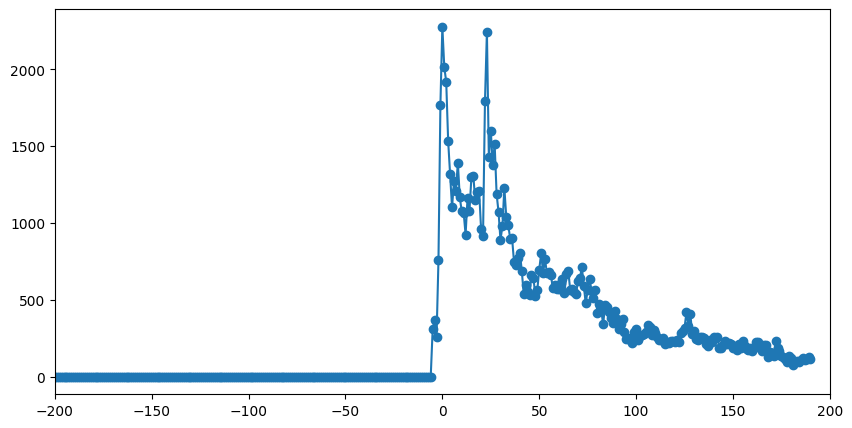

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temp_df['centered_date'], temp_df['views'], marker='o', linestyle='-')
ax.set_xlim(-200, 200)

Now putting all of this together:

In [54]:
total_dict = {}
for name, values in total.items():
    df = pd.DataFrame(series_dict[name], columns =['views']).fillna(0)
    maximum_date = df[df['views'] == df['views'].max()].index
    df['date'] = df.index
    df['centered_date'] = df.date.apply(lambda x: (x-maximum_date).days.item())
    total_dict[name] = df

In [55]:
for index, data in enumerate(total_dict):
    print(data)

High_Cookie
Strangers_Again
My_Demon
Longing_for_You
Intern
Why_R_U?
Doona!
Love_to_Hate_You
Race
Boyhood
Divorce_Attorney_Shin
The_Story_of_Park's_Marriage_Contract
Love_Tractor
Twinkling_Watermelon
Live_Your_Own_Life
A_Time_Called_You
A_Breeze_of_Love
Fling
Delivery_Man
King_the_Land
Our_Blooming_Youth
Agency
Evilive
Numbers
Woman_in_a_Veil
Tale_of_the_Nine-Tailed_1938
The_Real_Has_Come!
Apple_of_My_Eye
Our_Dating_Sim
Castaway_Diva
Oasis
Moving
Family:_The_Unbreakable_Bond
Destined_with_You
AI
Celebrity
Revenant
Not_Others
My_Man_Is_Cupid
Cold_Blooded_Intern
Moon_in_the_Day
Behind_Your_Touch
Korea-Khitan_War
See_You_in_My_19th_Life
Tree_Man
Epilogue
Kokdu:_Season_of_Deity
The_Heavenly_Idol
Heartbeat
Mask_Girl
Call_It_Love
Daily_Dose_of_Sunshine
To_Be_Honest
Brain_Works
Durian's_Affair
The_Third_Marriage
Meant_to_Be
Song_of_the_Bandits
The_Worst_of_Evil
My_Lovely_Liar
Maestra:_Strings_of_Truth
My_Dearest
Stealer:_The_Treasure_Keeper
The_Secret_Romantic_Guesthouse
Death's_Game
True_to_

Let's only print 10:

IndexError: index 10 is out of bounds for axis 0 with size 10

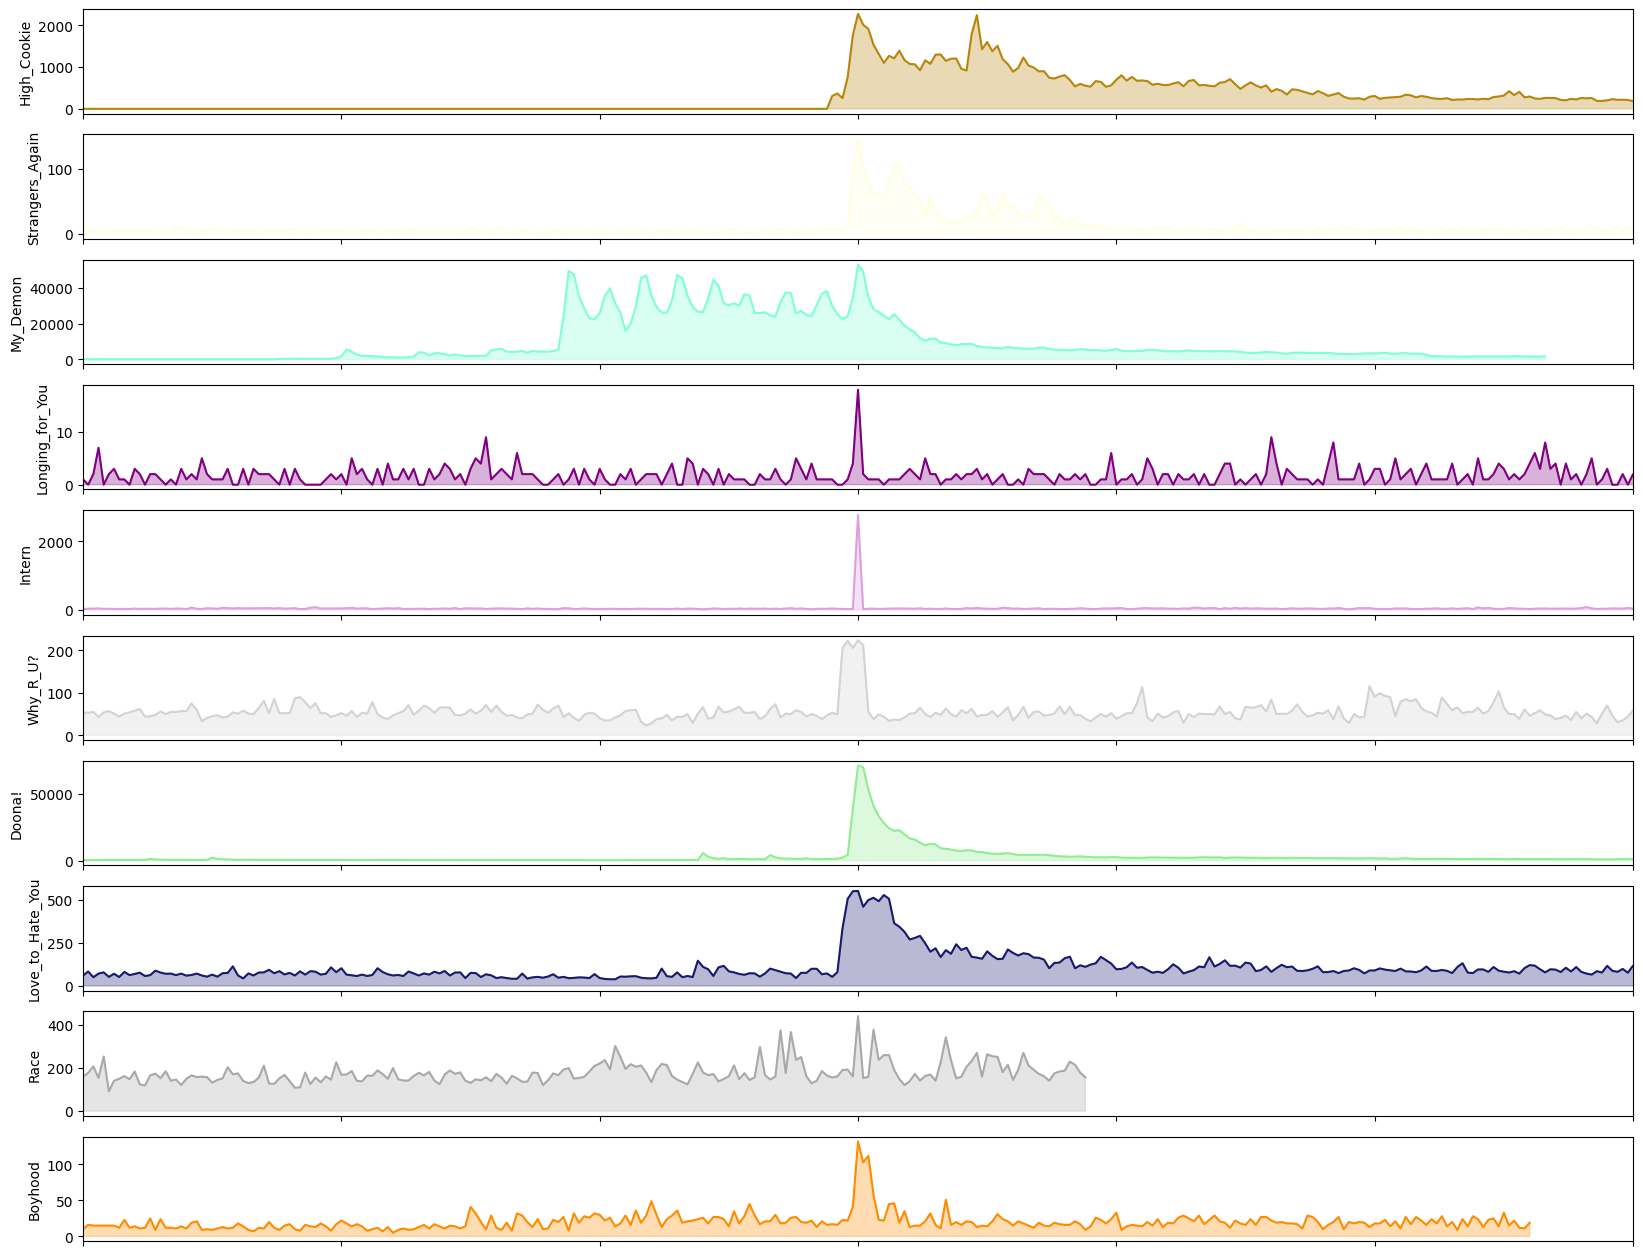

In [58]:
# the plot related color choices are from GenAI
import random
import matplotlib.colors as mcolors
color_names = list(mcolors.CSS4_COLORS.keys())

fig, axes = plt.subplots(10,1, figsize=(20, 16)) # only plotting 10 of the kdramas I have 

for index, data in enumerate(total_dict):
    ax = axes[index]

    random_color = random.choice(color_names)
    ax.plot(total_dict[data]["centered_date"], total_dict[data]["views"], color=random_color)
    ax.fill_between(total_dict[data]["centered_date"], total_dict[data]["views"], color=random_color, alpha=0.3)
    ax.set_xticklabels([])
    ax.set_xlim(-150, 150) # to make sure that the graphs are not too dragged out
    ax.set_ylabel(data)
